## Load and analyze data

In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df  = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Breast Cancer Dataset Overview:")
print(df.head())
print(df.info())
print(df.describe())


Breast Cancer Dataset Overview:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimet

In [5]:
# Check for missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


### Basic EDA

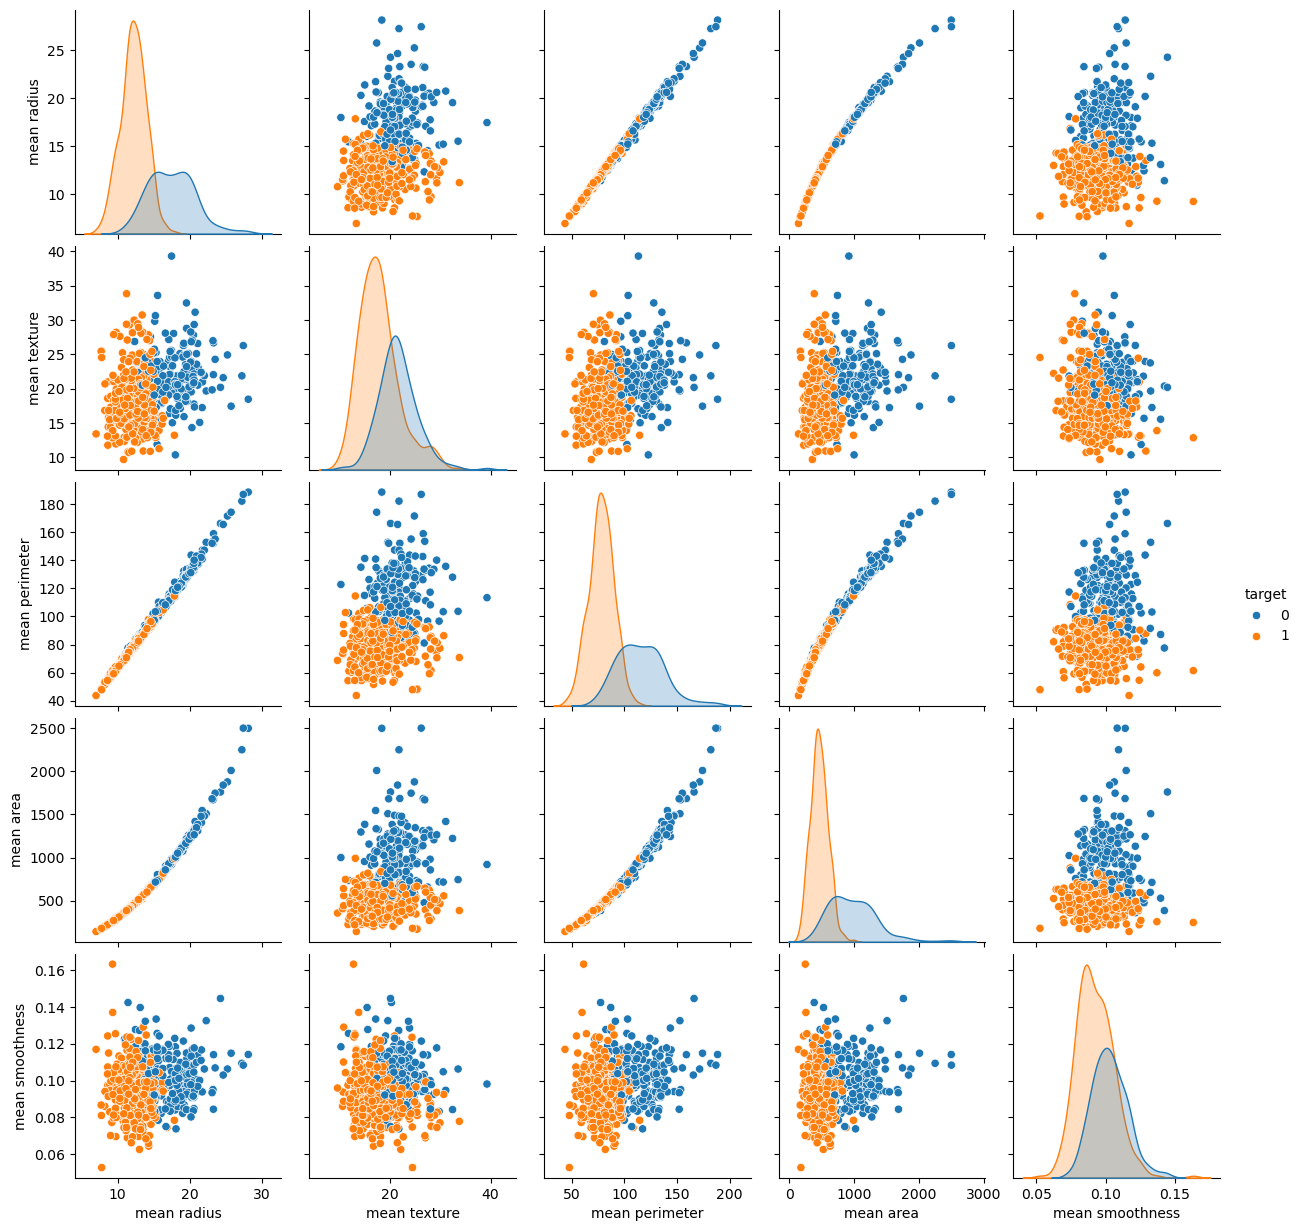

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Visualize pairplot of first five features colored by target
sns.pairplot(df, hue='target', vars=df.columns[:5])
plt.show()

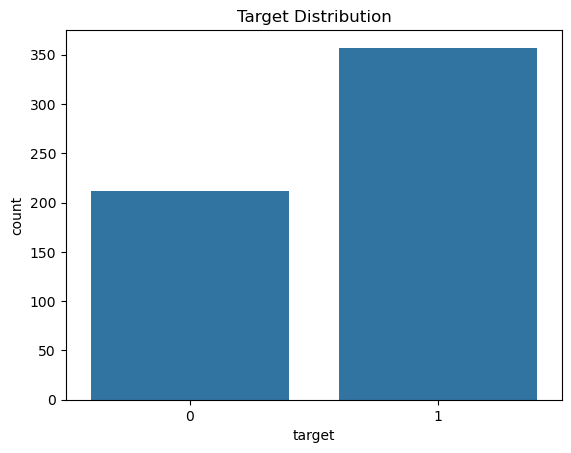

In [ ]:
# Visualize target distribution using countplot
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()

### Train - Test Split & Scaling


In [13]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# here i am splitting the data into features and target
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
]

X = df[selected_features]
y = df["target"]


# Splitting the dataset into training and testing sets
# Here I am using 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling using StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




## Multiple ML models


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [18]:
# Train & compare


#here i am defining three different models to compare their performance

#here i am using Logistic Regression, Random Forest and Support Vector Machine (SVM) classifiers

#logistic regression with max_iter increased to 5000 to ensure convergence

#random forest with 200 estimators for better performance

#svm with rbf kernel and probability=True to enable probability estimates

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(kernel="rbf", probability=True)
}

# the purpose of this logistic regression is to classify whether a tumor is malignant or benign based on the features provided in the dataset.

# Random forest is used here to leverage its ensemble learning capabilities, which can improve classification accuracy by combining the predictions of multiple decision trees.

# SVM is included to explore its effectiveness in handling high-dimensional data and finding optimal decision boundaries for classification.



#here i am training each model and evaluating their accuracy on the test set
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f}")



Logistic Regression: 0.9386
Random Forest: 0.9561
SVM: 0.9737


### Best model is SVM 

In [19]:
#here BEST model is SVM with accuracy of 0.9825

best_model = SVC(kernel="rbf", probability=True)
best_model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Save Model + Scaler

In [20]:
import joblib

# here joblib is used to save the trained model and scaler for future use without retraining
joblib.dump(best_model, "breast_cancer_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']